In [1]:

import requests
import json
from pathlib import Path
from io import BytesIO
import openpyxl
import csv
import pickle
from pprint import pprint
from box_sdk_gen import BoxClient, BoxDeveloperTokenAuth

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot

import imblearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer, recall_score, fbeta_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from scipy import stats

from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


#### Add session token 

In [2]:

token = 'token_here' #Define Token 

auth = BoxDeveloperTokenAuth(token=token)
client = BoxClient(auth=auth)
HEADERS = {"Authorization": f"Bearer {token}"}

## Data Prep

### Define functions 

In [3]:
# Box read and write 
def read_box_folder(path, start_id="0"):
    path_split = path.strip("/").split("/")
    folder_id = start_id

    # Walk through the folder path
    for folder_name in path_split:
        url = f"https://api.box.com/2.0/folders/{folder_id}/items?limit=1000"
        res = requests.get(url, headers=HEADERS)
        res.raise_for_status()
        data = res.json()

        matching = [f["id"] for f in data["entries"] if f["name"] == folder_name and f["type"] == "folder"]
        if not matching:
            raise ValueError(f"Folder not found: {folder_name}")
        folder_id = matching[0]

    # Collect all entries with pagination
    limit = 1000
    offset = 0
    entries = []

    while True:
        url = f"https://api.box.com/2.0/folders/{folder_id}/items?limit={limit}&offset={offset}"
        res = requests.get(url, headers=HEADERS)
        res.raise_for_status()
        data = res.json()

        entries.extend([{"id": f["id"], "name": f["name"], "type": f["type"]} for f in data["entries"]])

        if offset + limit >= data["total_count"]:
            break
        offset += limit

    return pd.DataFrame(entries)
    
def read_box_file(path, filename):
    folder_contents = read_box_folder(path)
    file_row = folder_contents[(folder_contents["name"] == filename) & (folder_contents["type"] == "file")]
    if file_row.empty:
        raise ValueError(f"File not found: {filename}")
    
    file_id = file_row.iloc[0]["id"]
    download_url = f"https://api.box.com/2.0/files/{file_id}/content"
    
    res = requests.get(download_url, headers=HEADERS)
    res.raise_for_status()
    
    # Save to temporary file (or keep in memory)
    tmp_path = Path(f"/tmp/{filename}")
    tmp_path.write_bytes(res.content)
    
    return tmp_path



# Store results 

def store_results(results, experiment_id, y, X, model, roc_auc, best_threshold, C_parameters, cr, cm):
    results[experiment_id] = {
        "experiment_id": experiment_id,
        "outcome": y.name,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "variables": list(X.columns),
        "pipeline": model,
        'roc auc': roc_auc,
        "best_threshold": best_threshold,
        "C parameters" : C_parameters,
        "performance": cr,
        "confusion_matrix": cm
    }
    return results



# Plotting 

def plot_normality(data, var_unnormalized, var_normalized):
    fig, axes = plt.subplots (2,2, figsize = (8,5))
    
    sns.histplot(data, x=var_unnormalized, color='green', fill=True, ax=axes[0,0])
    axes[0,0].set_title("Unnormalized Hist")
    axes[0,0].set_ylabel('Density')
    # axes[0,0].set_xlim(0, 3000)
    
    
    sns.histplot(data, x=var_normalized, color='blue', fill=True, ax=axes[0,1])
    axes[0,1].set_title("Normalized Hist")
    axes[0,1].set_ylabel('Density')
    # axes[0,1].set_xlim(0, 12)
    # axes[0,1].set_ylim(0, 200000)
    
    
    qqplot(data[var_unnormalized], line='s',ax=axes[1,0])
    axes[1,0].set_title("Unnormalized QQPlot")
    
    
    qqplot(data[var_normalized], line='s',ax=axes[1,1])
    axes[1,1].set_title("Normalized QQPlot")
    
    plt.tight_layout()
    return plt.show() 

def plot_normality_3(data, unnormalized, log, boxcox):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    
    # --- Row 1: Histograms ---
    sns.histplot(data, x=unnormalized, color='green', fill=True, ax=axes[0,0])
    axes[0,0].set_title(f"Unnormalized: {unnormalized}")
    
    sns.histplot(data, x=log, color='blue', fill=True, ax=axes[0,1])
    axes[0,1].set_title(f"Log: {log}")
    
    sns.histplot(data, x=boxcox, color='purple', fill=True, ax=axes[0,2])
    axes[0,2].set_title(f"Box-Cox: {boxcox}")
    
    # --- Row 2: QQ Plots ---
    qqplot(data[unnormalized].dropna(), line='s', ax=axes[1,0])
    axes[1,0].set_title("Unnormalized QQ")
    
    qqplot(data[log].dropna(), line='s', ax=axes[1,1])
    axes[1,1].set_title("Log QQ")
    
    qqplot(data[boxcox].dropna(), line='s', ax=axes[1,2])
    axes[1,2].set_title("Box-Cox QQ")
    
    plt.tight_layout()
    plt.show()


### Load Data

In [4]:
# Read Files in from Box 
df_summary_statistics_path = read_box_file('Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned/Baseline_minimallyprocessed/20260227','summary_statistics_freeview_t1_processed.xlsx')
outcomes_data_path = read_box_file('Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned','outcomes_data_calculated_2.15.26.xlsx')
cssrs_data_path = read_box_file('Freeview 2025/files from BEST folder/Data (from BEST_project on server)/Eyetracking Cleaned','cssrs_t1_2.7.26.xlsx')

# Read in summary stats
df_summary_statistics = pd.read_excel(df_summary_statistics_path).drop('Group', axis=1) #remove group variable for later merge 
outcomes_data = pd.read_excel(outcomes_data_path)
cssrs_t1 = pd.read_excel(cssrs_data_path)

In [6]:
#Merge df
summary_statistics = df_summary_statistics.merge(outcomes_data, left_on='subject', right_on='ParticipantName')
summary_statistics = summary_statistics.merge(cssrs_t1, how = 'left', left_on='subject', right_on='PtID') 
summary_statistics = summary_statistics.drop('PtID', axis=1)

### Transform Variables

#### Renaming and recoding

In [7]:
# Rename variables shorter
old_names = [
    "SuicideFixationTime", "SocialFixationTime", "NeutralFixationTime", "DysphoricFixationTime","BackgroundFixationTime",
    "SuicideMeanFixationTimeByTrial", "SocialMeanFixationTimeByTrial", "NeutralMeanFixationTimeByTrial", "DysphoricMeanFixationTimeByTrial", "BackgroundMeanFixationTimeByTrial",
    "SuicideFixationCount", "SocialFixationCount", "NeutralFixationCount", "DysphoricFixationCount","BackgroundFixationCount",
    "SuicideMeanFixationCountByTrial", "SocialMeanFixationCountByTrial", "NeutralMeanFixationCountByTrial", "DysphoricMeanFixationCountByTrial","BackgroundMeanFixationCountByTrial",
    "SuicidePupilSize", "SocialPupilSize", "NeutralPupilSize", "DysphoricPupilSize","BackgroundPupilSize",
    "SuicideMeanPupilByTrial", "SocialMeanPupilByTrial", "NeutralMeanPupilByTrial", "DysphoricMeanPupilByTrial", "BackgroundMeanPupilByTrial"]

new_names = [
    "SuicideTime", "SocialTime", "NeutralTime", "DysphoricTime","BackgroundTime",
    "SuicideTimeByTrial", "SocialTimeByTrial", "NeutralTimeByTrial", "DysphoricTimeByTrial", "BackgroundTimeByTrial",
    "SuicideCount", "SocialCount", "NeutralCount", "DysphoricCount","BackgroundCount",
    "SuicideCountByTrial", "SocialCountByTrial", "NeutralCountByTrial", "DysphoricCountByTrial","BackgroundCountByTrial",
    "SuicidePupil", "SocialPupil", "NeutralPupil", "DysphoricPupil","BackgroundPupil",
    "SuicidePupilByTrial", "SocialPupilByTrial", "NeutralPupilByTrial", "DysphoricPupilByTrial","BackgroundPupilByTrial"]


rename_dict = dict(zip(old_names, new_names))
summary_statistics.rename(columns=rename_dict, inplace=True)


# Create variables recoding Control and SI as one category
summary_statistics['outcome_t3_R'] = summary_statistics['outcome_t3'].replace({"Control": "No SA", "SI": "No SA"})
summary_statistics['outcome_t2_R'] = summary_statistics['outcome_t2'].replace({"Control": "No SA", "SI": "No SA"})
summary_statistics['outcome_t1_R'] = summary_statistics['outcome_t1'].replace({"Control": "No SA", "SI": "No SA"})
summary_statistics['outcome_past3mo_t1_R'] = summary_statistics['outcome_past3mo_t1'].replace({"Control": "No SA", "SI": "No SA"})

print(summary_statistics['outcome_t3_R'].value_counts())


# Convert variable types
summary_statistics["ExperimentVersion"] = summary_statistics["ExperimentVersion"].astype('category')
summary_statistics["Group"] = summary_statistics["Group"].astype('category')
summary_statistics["TrialsKept"] = summary_statistics["TrialsKept"].apply(lambda x: int(x))

summary_statistics["outcome_t1"] = summary_statistics["outcome_t1"].astype('category')
summary_statistics["outcome_past3mo_t1"] = summary_statistics["outcome_past3mo_t1"].astype('category')
summary_statistics["outcome_t3"] = summary_statistics["outcome_t3"].astype('category')

summary_statistics["DEMGB001"] = summary_statistics["DEMGB001"].astype('category') #Sex
summary_statistics["DEMGB002"] = summary_statistics["DEMGB002"].astype('Int64') #Age
summary_statistics["CS24_LT_t1"] = summary_statistics["CS24_LT_t1"].astype('Int64') #Passive and Active SI Lifetime
summary_statistics["CS25_LT_t1"] = summary_statistics["CS25_LT_t1"].astype('Int64') #Active SI Lifetime


# dummy code Sex and rename Age and Sex
summary_statistics = pd.get_dummies(summary_statistics, columns=['DEMGB001'], dtype=int).copy()
summary_statistics = summary_statistics.rename(columns = {'DEMGB001_1.0':'Female','DEMGB001_2.0':'Male','DEMGB002':'Age'})




outcome_t3_R
No SA    108
SA        50
Name: count, dtype: int64


#### Log transformation

In [8]:
summary_statistics["SuicideTime_log"] = summary_statistics["SuicideTime"].apply(lambda x: float(math.log1p(x)))
summary_statistics["SocialTime_log"] = summary_statistics["SocialTime"].apply(lambda x: float(math.log1p(x)))
summary_statistics["NeutralTime_log"] = summary_statistics["NeutralTime"].apply(lambda x: float(math.log1p(x)))
summary_statistics["DysphoricTime_log"] = summary_statistics["DysphoricTime"].apply(lambda x: float(math.log1p(x)))
summary_statistics["BackgroundTime_log"] = summary_statistics["BackgroundTime"].apply(lambda x: float(math.log1p(x)))

summary_statistics["SuicideTimeByTrial_log"] = summary_statistics["SuicideTimeByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["SocialTimeByTrial_log"] = summary_statistics["SocialTimeByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["NeutralTimeByTrial_log"] = summary_statistics["NeutralTimeByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["DysphoricTimeByTrial_log"] = summary_statistics["DysphoricTimeByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["BackgroundTimeByTrial_log"] = summary_statistics["BackgroundTimeByTrial"].apply(lambda x: float(math.log1p(x)))

summary_statistics["SuicideCount_log"] = summary_statistics["SuicideCount"].apply(lambda x: float(math.log1p(x)))
summary_statistics["SocialCount_log"] = summary_statistics["SocialCount"].apply(lambda x: float(math.log1p(x)))
summary_statistics["NeutralCount_log"] = summary_statistics["NeutralCount"].apply(lambda x: float(math.log1p(x)))
summary_statistics["DysphoricCount_log"] = summary_statistics["DysphoricCount"].apply(lambda x: float(math.log1p(x)))
summary_statistics["BackgroundCount_log"] = summary_statistics["BackgroundCount"].apply(lambda x: float(math.log1p(x)))

summary_statistics["SuicideCountByTrial_log"] = summary_statistics["SuicideCountByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["SocialCountByTrial_log"] = summary_statistics["SocialCountByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["NeutralCountByTrial_log"] = summary_statistics["NeutralCountByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["DysphoricCountByTrial_log"] = summary_statistics["DysphoricCountByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["BackgroundCountByTrial_log"] = summary_statistics["BackgroundCountByTrial"].apply(lambda x: float(math.log1p(x)))

summary_statistics["SuicidePupil_log"] = summary_statistics["SuicidePupil"].apply(lambda x: float(math.log1p(x)))
summary_statistics["SocialPupil_log"] = summary_statistics["SocialPupil"].apply(lambda x: float(math.log1p(x)))
summary_statistics["NeutralPupil_log"] = summary_statistics["NeutralPupil"].apply(lambda x: float(math.log1p(x)))
summary_statistics["DysphoricPupil_log"] = summary_statistics["DysphoricPupil"].apply(lambda x: float(math.log1p(x)))
summary_statistics["BackgroundPupil_log"] = summary_statistics["BackgroundPupil"].apply(lambda x: float(math.log1p(x)))


summary_statistics["SuicidePupilByTrial_log"] = summary_statistics["SuicidePupilByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["SocialPupilByTrial_log"] = summary_statistics["SocialPupilByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["NeutralPupilByTrial_log"] = summary_statistics["NeutralPupilByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["DysphoricPupilByTrial_log"] = summary_statistics["DysphoricPupilByTrial"].apply(lambda x: float(math.log1p(x)))
summary_statistics["BackgroundPupilByTrial_log"] = summary_statistics["BackgroundPupilByTrial"].apply(lambda x: float(math.log1p(x)))

summary_statistics["CS24_LT_t1_log"] = summary_statistics["CS24_LT_t1"].apply(lambda x: float(math.log1p(x)))

#### Drop incomplete rows 

In [9]:
print('original n = ', len(summary_statistics))
summary_statistics = summary_statistics.dropna()
print('n after dropping NAs =', len(summary_statistics))

print('data check' , len(summary_statistics['subject'].unique()))

original n =  158
n after dropping NAs = 142
data check 142


In [11]:
summary_statistics.describe()

,subject,TrialsKept,SuicideTime,NeutralTime,SocialTime,DysphoricTime,BackgroundTime,SuicideCount,NeutralCount,SocialCount,...,SocialPupil_log,NeutralPupil_log,DysphoricPupil_log,BackgroundPupil_log,SuicidePupilByTrial_log,SocialPupilByTrial_log,NeutralPupilByTrial_log,DysphoricPupilByTrial_log,BackgroundPupilByTrial_log,CS24_LT_t1_log
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,...,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,285.605634,8.366197,51.542958,44.800570,50.482761,39.421739,14.075880,15472.323944,13448.338028,15154.288732,...,1.516555,1.517384,1.522566,1.564715,1.522689,1.514661,1.516683,1.519992,1.566189,0.939400
std,91.950261,2.386365,32.732959,21.811301,26.663005,16.781156,15.149701,9826.049887,6546.896546,8003.086137,...,0.135741,0.134802,0.135337,0.144709,0.133822,0.133856,0.133772,0.134358,0.146415,0.940262
min,118.000000,2.000000,1.602000,3.781000,8.217000,2.198000,1.259000,482.000000,1137.000000,2467.000000,...,1.208661,1.205251,1.201660,1.222014,1.242470,1.210544,1.212248,1.216318,1.213328,0.000000
25%,206.500000,7.000000,26.420500,27.498750,34.122750,26.539500,6.835000,7930.750000,8253.750000,10243.250000,...,1.430098,1.429378,1.438094,1.473197,1.443475,1.426950,1.436364,1.439473,1.477135,0.000000
50%,291.500000,9.000000,48.686000,44.567500,47.467000,38.608000,9.521500,14615.500000,13376.500000,14246.000000,...,1.521054,1.523409,1.531209,1.576158,1.521631,1.518876,1.521705,1.522927,1.578074,0.693147
75%,356.750000,10.000000,64.843500,57.135750,61.927750,52.400500,14.550000,19461.000000,17150.750000,18585.250000,...,1.610920,1.604074,1.609583,1.674882,1.613696,1.610358,1.599148,1.606690,1.682460,1.609438
max,449.000000,11.000000,210.830000,125.609000,127.328000,87.849000,109.317000,63297.000000,37700.000000,38210.000000,...,1.883839,1.908524,1.912353,1.993693,1.881727,1.882050,1.890999,1.898215,1.982918,3.332205


## Preprocessing

#### Test Train Split on outcome of interest

In [12]:
# outcome = 'outcome_past3mo_t1_R'
outcome = 'outcome_t3_R'


X_train_all, X_test_all, y_train, y_test = train_test_split(summary_statistics.drop(outcome,axis = 1), #Features (X)
                                                   summary_statistics[outcome], # Outcome (Y)
                                                   test_size = 0.3, #Split
                                                    stratify = summary_statistics[outcome], #Preserve class proportions in both sets 
                                                  random_state = 42) #Set Seed 



print("Training outcome split and percentage")
print(y_train.value_counts())
print(y_train.value_counts()/len(y_train),"\n\n")

print("Test outcome split and percentage")
print(y_test.value_counts())
print(y_test.value_counts()/len(y_test))


train_subjects = X_train_all['ParticipantName'].to_list()
test_subjects = X_test_all['ParticipantName'].to_list()

print('Train subjects',  train_subjects)
print()
print('Test subjects', test_subjects)

Training outcome split and percentage
outcome_t3_R
No SA    65
SA       34
Name: count, dtype: int64
outcome_t3_R
No SA    0.656566
SA       0.343434
Name: count, dtype: float64 


Test outcome split and percentage
outcome_t3_R
No SA    28
SA       15
Name: count, dtype: int64
outcome_t3_R
No SA    0.651163
SA       0.348837
Name: count, dtype: float64
Train subjects [236, 254, 139, 448, 338, 353, 171, 347, 276, 145, 164, 354, 279, 253, 316, 363, 208, 137, 399, 125, 268, 346, 118, 149, 269, 283, 410, 373, 258, 400, 274, 237, 153, 295, 292, 303, 391, 244, 251, 325, 351, 357, 199, 187, 345, 326, 194, 144, 238, 332, 180, 136, 206, 334, 426, 291, 435, 423, 214, 430, 252, 148, 138, 277, 160, 150, 165, 317, 356, 349, 256, 321, 282, 377, 203, 223, 288, 205, 318, 371, 300, 190, 246, 359, 310, 337, 362, 440, 174, 226, 372, 158, 379, 294, 366, 231, 367, 439, 278]

Test subjects [380, 420, 210, 197, 230, 368, 401, 324, 133, 121, 161, 245, 434, 221, 271, 192, 296, 290, 382, 350, 229, 413, 193, 417

In [33]:
X_train_all['Male'].value_counts()
40/99

0.40404040404040403

In [35]:
X_test_all['Male'].value_counts()


0.3488372093023256

In [37]:
summary_statistics['Male'].value_counts()


0.3873239436619718

In [64]:
columns_to_transform = [
    "SuicideTime", "SocialTime", "NeutralTime", "DysphoricTime","BackgroundTime",
    "SuicideTimeByTrial", "SocialTimeByTrial", "NeutralTimeByTrial", "DysphoricTimeByTrial", "BackgroundTimeByTrial",
    "SuicideCount", "SocialCount", "NeutralCount", "DysphoricCount","BackgroundCount",
    "SuicideCountByTrial", "SocialCountByTrial", "NeutralCountByTrial", "DysphoricCountByTrial","BackgroundCountByTrial",
    "SuicidePupil", "SocialPupil", "NeutralPupil", "DysphoricPupil","BackgroundPupil",
    "SuicidePupilByTrial", "SocialPupilByTrial", "NeutralPupilByTrial", "DysphoricPupilByTrial","BackgroundPupilByTrial",
    "CS24_LT_t1"]


lambdas = {}

for col in columns_to_transform:

    new_col_name = f"{col}_bc"
    if col.startswith("CS"):
        transformed_data, lmbda = stats.boxcox(X_train_all[col]+1)
    else:
        transformed_data, lmbda = stats.boxcox(X_train_all[col])
    
    X_train_all[new_col_name] = transformed_data
    lambdas[new_col_name] = lmbda


In [285]:
# # Plot if comparing unnormalized and two other transformations
# plot_normality_3(X_train_all, unnormalized= "CS24_LT_t1", log = "CS24_LT_t1_log", boxcox = "CS24_LT_t1_bc")

# imageTypes = ['Suicide','Social','Neutral','Dysphoric']

#metric = 'Time'
# metric = 'TimeByTrial'
# metric = 'Count'
# metric = 'CountByTrial'
# metric = 'Pupil'
# metric = 'PupilByTrial'

# for image in imageTypes:
#         plot_normality_3(X_train_all, f"{image}{metric}", f"{image}{metric}_log", f"{image}{metric}_bc")



In [286]:
# # Plot if comparing unnormalized and one other transformation

# plot_normality(X_train_all, "CS24_LT_t1",  "CS24_LT_t1_bc")

# imageTypes = ['Suicide','Social','Neutral','Dysphoric']

# metric = 'Time'
# metric = 'TimeByTrial'
# metric = 'Count'
# metric = 'CountByTrial'
# metric = 'Pupil'
# metric = 'PupilByTrial'
# 
# for image in imageTypes:
#         plot_normality(X_train_all, f"{image}{metric}",  f"{image}{metric}_bc")



#### Define variables for dataframes
- Right now, X train/ X test contains all variables
- Use these lists to subset just X df features you want to build a model around

In [65]:
variables_Time = ["SuicideTime_log", "SocialTime_log", "NeutralTime_log", "DysphoricTime_log",  "BackgroundTime_log"]

variables_TimeByTrial = ["SuicideTimeByTrial_log", "SocialTimeByTrial_log", "NeutralTimeByTrial_log", "DysphoricTimeByTrial_log", "BackgroundTimeByTrial_log"]

variables_Count = ["SuicideCount_log", "SocialCount_log", "NeutralCount_log","DysphoricCount_log","BackgroundCount_log"]

variables_CountByTrial = ["SuicideCountByTrial_log","SocialCountByTrial_log", "NeutralCountByTrial_log", "DysphoricCountByTrial_log", "BackgroundCountByTrial_log"]

variables_Pupil = ["SuicidePupil_log",  "SocialPupil_log", "NeutralPupil_log", "DysphoricPupil_log", "BackgroundPupil_log"]

variables_PupilByTrial = ["SuicidePupilByTrial_log", "SocialPupilByTrial_log", "NeutralPupilByTrial_log", "DysphoricPupilByTrial_log", "BackgroundPupilByTrial_log"]


variables_demographics = ["TrialsKept", "Male", "Female", "Age",  "CS24_LT_t1_log"]
# variables_demographics = ["TrialsKept", "Male", "Female", "Age"]


variables_CSSRS_t1 = ['CS12_1mo_t1']



# # Write formulas
feature_sets = {
    "Count_Total": variables_Count + variables_demographics,
    "Count_Pupil_Total": variables_Count + variables_Pupil + variables_demographics,
    
    "Count_Trial": variables_CountByTrial + variables_demographics,
    "Count_Pupil_Trial": variables_CountByTrial + variables_PupilByTrial + variables_demographics,

    "Time_Total": variables_Time + variables_demographics,
    "Time_Pupil_Total": variables_Time + variables_Pupil + variables_demographics,
    
    "Time_Trial": variables_TimeByTrial + variables_demographics,
    "Time_Pupil_Trial": variables_TimeByTrial + variables_PupilByTrial + variables_demographics,

    "Pupil_Total": variables_Pupil + variables_demographics,
    "Pupil_Trial": variables_PupilByTrial + variables_demographics}



feature_sets_cssrs = {
    "Count_Total": variables_Count + variables_CSSRS_t1 + variables_demographics,
    "Count_Pupil_Total": variables_Count + variables_Pupil + variables_CSSRS_t1 + variables_demographics,
    
    "Count_Trial": variables_CountByTrial + variables_CSSRS_t1 + variables_demographics,
    "Count_Pupil_Trial": variables_CountByTrial + variables_PupilByTrial + variables_CSSRS_t1 + variables_demographics,

    "Time_Total": variables_Time + variables_CSSRS_t1 + variables_demographics,
    "Time_Pupil_Total": variables_Time + variables_Pupil + variables_CSSRS_t1 + variables_demographics,
    
    "Time_Trial": variables_TimeByTrial + variables_CSSRS_t1 + variables_demographics,
    "Time_Pupil_Trial": variables_TimeByTrial + variables_PupilByTrial + variables_CSSRS_t1 + variables_demographics,

    "Pupil_Total": variables_Pupil + variables_CSSRS_t1 + variables_demographics,
    "Pupil_Trial": variables_PupilByTrial + variables_CSSRS_t1 + variables_demographics}



## Model 1: Optimized to detect SA class


##### Scaling 
- Standard Scaling on numerical values
- One Hot Encoding on Categorical values

##### Handling Class imbalance
- Class weights = balanced
##### Classifier Type: 
- Logistic Regression (Predict Suicide Attempt Y/N)
##### Training 
- Grid search for C regularization parameter (optimized on SA f1 rather than overall model macro f1)
- Evaluate best probability threshold for class prediction (optimized on SA f1)


#### Evaluate Performance
- Overall Model Performance
    - f1_macro - harmonic mean of precision and recall
    - f2_macro - balancing precision and recall with greater emphasis on recall
- Suicde Attempt Model Performance
    - SA_recall - Minimizing false negatives
    - SA f1 - harmonic mean of precision and recall for SA class prediction
    - SA f2 - balancing precision and recall with greater emphasis on recall


F2 = balancing precision and recall with greater emphasis on recall
Recall = Out of all actual positives, how many were captured? (minimizing false negative)
Precision - When the model predicts a class, how often it is correct (minimizing false positives)

#### Define lists to iterate through

In [79]:
results = {}


# variableNames = ['Count_Total', 'Count_Pupil_Total','Count_Trial', 'Count_Pupil_Trial', 
#                   'Time_Total', 'Time_Pupil_Total', 'Time_Trial', 'Time_Pupil_Trial', 
#                  'Pupil_Total', 'Pupil_Trial']



variableNames = ['Count_Trial', 'Count_Pupil_Trial', 
                  'Time_Trial', 'Time_Pupil_Trial', 
                 'Pupil_Trial']


# covariateNames = ['CS12','No CSSRS']
covariateNames = ['No CSSRS']



#### Logistic Regression 

In [80]:
# # Define performance metric that GridSearchCV and probability threshold optimize

#Overall model
refit_metric, probability_threshold_metric = ['f1_macro', 'f1_macro']

# refit_metric, probability_threshold_metric = ['f2_macro', 'f2_macro']

# #SA Class
# refit_metric, probability_threshold_metric = ['f1_SA', 'f1_SA']
# refit_metric, probability_threshold_metric = ['f2_SA', 'f2_SA']


for variable in variableNames:
    
    for covariate in covariateNames:
        
        if covariate == 'CS12':
            experiment_id = f"{variable}_CS12"
            X_train = X_train_all[feature_sets_cssrs[variable]]
            # X_test  = X_test_all[feature_sets_cssrs[variable]]
            
        elif covariate == 'No CSSRS':
            experiment_id = f"{variable}_noCSSRS"
            X_train = X_train_all[feature_sets[variable]]
            # X_test  = X_test_all[feature_sets[variable]]
            
        categorical_features = ['Male','Female']
        numeric_features = [col for col in X_train.columns if col not in categorical_features]

        # # Instantiate model, balanced classes
        preprocesser = ColumnTransformer(
            transformers = [
                ('num', StandardScaler(), numeric_features)
                #,
                #('cat', OneHotEncoder(), categorical_features)
            ])
        
        model = Pipeline(steps =[
            ('preprocesser', preprocesser),
            ('classifier', LogisticRegression(
                max_iter=1000,
                solver='liblinear',
                class_weight='balanced',
                random_state = 42))])

        # # Set up search grid for best penalty and C regularization parameter
        param_grid = {
            'classifier__C': [.001, .01 ,.1, 1, 10, 100],
            'classifier__penalty':['l1','l2']}

        # # Define performance metrics of interest/ define metric prioritizing True positive of SA class 
        scoring = {
            "roc_auc": "roc_auc",
            "f1_macro": "f1_macro",
            "f2_macro": make_scorer(
                fbeta_score,
                beta = 2,
                average = 'macro'),
            "recall_SA": make_scorer(
                recall_score,
                pos_label = 'SA',
                average = 'binary'),
            "f1_SA": make_scorer(
                f1_score,
                pos_label = 'SA',
                average = 'binary'),
            "f2_SA": make_scorer(
                fbeta_score,
                beta = 2,
                pos_label = 'SA',
                average = 'binary')
        }

        
        # # Set up CV
        cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

        
        # # Search across grid for best parameters
        grid = GridSearchCV(
            model,
            param_grid = param_grid,
            cv = cv,
            scoring = scoring,
            refit = refit_metric,
            n_jobs = 1)

        
        # # Fit to best parameters
        grid.fit(X_train,y_train)
        C_parameters = grid.best_params_
    

        # # Predict based on cross validated estimates
        y_probs = cross_val_predict(
            grid.best_estimator_,
            X_train,
            y_train,
            cv = cv,
            method= 'predict_proba')[:,1]

        # # Evaluate best probability threshold for prediction cutoff
        thresholds = np.linspace (.01,1,101)
        
        results_probthresh = []
        
        for t in thresholds:
            y_pred_thresh = np.where(y_probs >= t, 'SA', 'No SA')
            f1_macro = f1_score(y_train, y_pred_thresh, average = 'macro')
            f2_macro = fbeta_score(y_train,y_pred_thresh,beta = 2, average = 'macro')
            f1_SA = f1_score(y_train, y_pred_thresh,pos_label = 'SA',average = 'binary')
            f2_SA = fbeta_score(y_train, y_pred_thresh, beta=2, pos_label= 'SA', average = 'binary')
            recall_SA = recall_score(y_train, y_pred_thresh, pos_label= 'SA', average= 'binary')
            
            results_probthresh.append({'threshold': t, 
                                       'f1_macro' : f1_macro,
                                       'f2_macro' : f2_macro,
                                       'f1_SA': f1_SA, 
                                       'f2_SA': f2_SA,
                                       'recall_SA': recall_SA
                                       })


        roc_auc = roc_auc_score(y_train, y_probs, average= 'macro')
        
        df_thresh = pd.DataFrame(results_probthresh)
        
        #Take best threshold for performance metric of interest (here f1 SA)
        best_row = df_thresh.loc[df_thresh[probability_threshold_metric].idxmax()]
        best_threshold = best_row['threshold']

        # Use best threshold when determining y_prediction
        y_pred_best_thresh = np.where(y_probs > best_threshold,'SA','No SA')


        #Define confusion matrix
        cm = confusion_matrix(y_train, y_pred_best_thresh)

        # Define classification report
        cr = classification_report(y_train, y_pred_best_thresh,output_dict=True)


        # Define f2 and add it to classification report 
        f2_SA_best_thresh = fbeta_score(
            y_train,
            y_pred_best_thresh,
            beta = 2,
            pos_label= 'SA',
            average = 'binary')


        f2_macro_best_thresh = fbeta_score(
            y_train,
            y_pred_best_thresh,
            beta = 2,
            average = 'macro')
        
        cr['SA']['f2-score'] = f2_SA_best_thresh
        cr['macro avg']['f2-score'] = f2_macro_best_thresh


        # # Store results
        results = store_results(
            results,
            experiment_id,
            y_train,
            X_train,
            model,
            roc_auc,
            best_threshold,
            C_parameters,
            cr,
            cm)

        

#### Get best fitting models based on different performance metrics

In [81]:

print('When optimized on', refit_metric, ', these are the best performing models based on ')
print()

# # Inspect best overall f1 
best_model_f1_macro, best_value_f1_macro = max(
    ((m, r["performance"]["macro avg"]['f1-score']) for m, r in results.items()),
    key=lambda x: x[1])
print('f1_macro:', best_model_f1_macro, ':', np.round(best_value_f1_macro,3))


# # Inspect best overall f2 
best_model_f2_macro, best_value_f2_macro = max(
    ((m, r["performance"]["macro avg"]['f2-score']) for m, r in results.items()),
    key=lambda x: x[1])
print('f2_macro:', best_model_f2_macro, ':', np.round(best_value_f2_macro,3))


# # Inspect best SA f1 
best_model_f1_SA, best_value_f1_SA = max(
    ((m, r["performance"]["SA"]['f1-score']) for m, r in results.items()),
    key=lambda x: x[1])
print('f1_Suicide Class:', best_model_f1_SA, ':',np.round(best_value_f1_SA,3))


# # Inspect best SA f2 
best_model_f2_SA, best_value_f2_SA = max(
    ((m, r["performance"]["SA"]['f2-score']) for m, r in results.items()),
    key=lambda x: x[1])
print('f2_Suicde Class:', best_model_f2_SA, ':',np.round(best_value_f2_SA,3))


# # Inspect best overall f2 
best_model_rocauc_macro, best_value_rocauc_macro = max(
    ((m, r["roc auc"]) for m, r in results.items()),
    key=lambda x: x[1])
print('roc_auc:', best_model_rocauc_macro, ':', np.round(best_value_rocauc_macro,3))




When optimized on f1_macro , these are the best performing models based on 

f1_macro: Count_Pupil_Trial_noCSSRS : 0.706
f2_macro: Count_Pupil_Trial_noCSSRS : 0.717
f1_Suicide Class: Count_Pupil_Trial_noCSSRS : 0.65
f2_Suicde Class: Count_Pupil_Trial_noCSSRS : 0.714
roc_auc: Count_Pupil_Trial_noCSSRS : 0.716


In [82]:
print(f"Within models optimized on {refit_metric}, show the classification report and confusion matrix of the model with the highest secondary metric of interest [f1 macro, f2 macro, f1 SA, or f2 SA]")
#print()

# best = results[best_model_f1_macro]
# best = results[best_model_f2_macro]

# best = results[best_model_f1_SA]
# best = results[best_model_f2_SA]

best = results[best_model_rocauc_macro]


Within models optimized on f1_macro, show the classification report and confusion matrix of the model with the highest secondary metric of interest [f1 macro, f2 macro, f1 SA, or f2 SA]


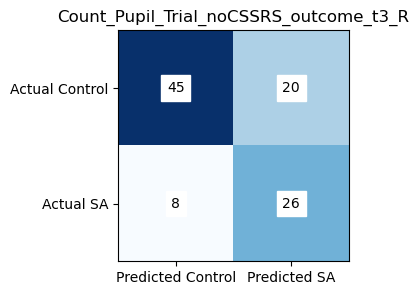


               No SA         SA  accuracy  macro avg  weighted avg
precision   0.849057   0.565217  0.717172   0.707137      0.751576
recall      0.692308   0.764706  0.717172   0.728507      0.717172
f1-score    0.762712   0.650000  0.717172   0.706356      0.724003
support    65.000000  34.000000  0.717172  99.000000     99.000000
f2-score         NaN   0.714286  0.717172   0.716568           NaN

SA F1 recall =  0.65

SA F2 recall =  0.714

Probability Threshold optimized on f1_macro = 0.5

Regularization Parameters optimized on f1_macro =  {'classifier__C': 1, 'classifier__penalty': 'l1'}



In [83]:

# # Plot confusion matrix
cm_best = best['confusion_matrix']

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(cm_best,cmap = 'Blues')

ax.grid(False)
plt.title(f"{best['experiment_id']}_{best['outcome']}")
ax.xaxis.set(ticks=(0, 1), ticklabels=('Predicted Control', 'Predicted SA'))
ax.yaxis.set(ticks=(0, 1), ticklabels=('Actual Control', 'Actual SA'))
ax.set_ylim(1.5, -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_best[i, j], ha='center', va='center', color='black',backgroundcolor = 'white')
plt.show()

print()
# Print classification report 
print(pd.DataFrame(best['performance']))

print()
print('SA F1 recall = ', np.round(best['performance']['SA']['f1-score'],3))
print()
print('SA F2 recall = ', np.round(best['performance']['SA']['f2-score'],3))
print()
print('Probability Threshold optimized on', probability_threshold_metric, '=',np.round(best['best_threshold'],2))
print()
print('Regularization Parameters optimized on', refit_metric,'= ', best['C parameters'])
print()

In [84]:

# # Save pickle file 
# date = '03072026'
# outcome = y_train.name.split("_")[1]
# fileName = f"LogRegOpt_{refit_metric}_{outcome}_{date}.pkl"
# pd.to_pickle(results, fileName)

